# ☀️ Start Energy AI — 02. Análisis Exploratorio de Datos (EDA)

**Proyecto:** Predicción de Generación Fotovoltaica y Optimización de Consumo
**Autora:** Camila Rabelo
**Notebook anterior:** `01_ETL.ipynb` (genera `energia_limpia.csv`)
**Siguiente notebook:** `03_Feature_Engineering.ipynb`

Este notebook parte del dataset horario ya limpio y unificado (`energia_limpia.csv`),
producto del ETL multi-fuente (REE, ESIOS, AEMET, PVGIS, Datadis). Aquí **no se hace
limpieza** — solo exploración, estadística descriptiva y visualización — para entender
qué variables tienen relación real con la generación fotovoltaica y el consumo, antes
de construir features para el modelo.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="darkgrid")
pd.set_option("display.max_columns", 50)

# Paleta coherente con la identidad del proyecto
COLOR_NAVY = "#0B0F19"
COLOR_GOLD = "#D4AF37"
plt.rcParams["figure.figsize"] = (14, 6)


## 1. Carga del dataset limpio

Se busca `energia_limpia.csv` en las rutas más habituales del proyecto, para que el
notebook funcione sin importar si lo abres desde la carpeta `notebooks/` o la raíz.

In [2]:
from pathlib import Path

# Punto de partida: dónde cree Python que está parado ahora mismo
print("Directorio de trabajo actual:", Path.cwd())

# Busca energia_limpia.csv en todo el proyecto, sin importar la carpeta desde donde se ejecute
candidatos = list(Path.cwd().parent.rglob("energia_limpia.csv")) + list(Path.cwd().rglob("energia_limpia.csv"))
candidatos = list(set(candidatos))

if candidatos:
    ruta_dataset = candidatos[0]
    print(f"Dataset encontrado en: {ruta_dataset.resolve()}")
    if len(candidatos) > 1:
        print("Aviso: se encontró más de una copia:", [str(c) for c in candidatos])
else:
    ruta_dataset = None
    print("[AVISO] No se encontró energia_limpia.csv en ningún lado del proyecto.")
    print("Verifica que 01_ETL.ipynb ya lo haya generado en la carpeta processed/.")

Directorio de trabajo actual: c:\Users\Santiago\Desktop\Star Energy AI\Start-Energy-AI\notebooks
Dataset encontrado en: C:\Users\Santiago\Desktop\Star Energy AI\Start-Energy-AI\data\processed\energia_limpia.csv


In [3]:
df = pd.read_csv(ruta_dataset, parse_dates=["fecha"] if "fecha" in pd.read_csv(ruta_dataset, nrows=0).columns else None)

# Si la columna de fecha tiene otro nombre o viene como índice, ajusta aquí:
if "fecha" in df.columns:
    df = df.set_index("fecha")
elif df.index.name is None and pd.api.types.is_object_dtype(df.iloc[:, 0]):
    df.iloc[:, 0] = pd.to_datetime(df.iloc[:, 0], errors="coerce")
    df = df.set_index(df.columns[0])

df.index = pd.to_datetime(df.index, utc=True, errors="coerce")
df = df.sort_index()

print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
print(f"Rango temporal: {df.index.min()} → {df.index.max()}")
df.head()


Filas: 9640 | Columnas: 16
Rango temporal: 2022-12-31 23:00:00+00:00 → 2025-03-31 23:00:00+00:00


c:\Users\Santiago\anaconda3\Lib\site-packages\pandas\core\indexes\base.py:7654: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)


,demanda_ree_kwh,generacion_total_ree_kwh,renovables_ree_kwh,solar_esios_kwh,eolica_esios_kwh,consumo_casa_datadis_kwh,tmed,prec,tmin,tmax,sol,hrMedia,pvgis_meteo_var_0,pvgis_meteo_var_1,pvgis_prod_media_diaria_kwh,pvgis_prod_media_mensual_kwh
datetime_clean,,,,,,,,,,,,,,,,
2022-12-31 23:00:00+00:00,21489.0,68509.558750,274038.235000,6465.0,7054.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.78,55.16
2022-12-31 23:05:00+00:00,21526.0,68554.869112,274219.476446,6468.0,6702.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.78,55.16
2022-12-31 23:10:00+00:00,21545.0,68600.179473,274400.717892,6470.0,6295.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.78,55.16
2022-12-31 23:15:00+00:00,21535.0,68645.489835,274581.959339,6467.0,6230.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.78,55.16
2022-12-31 23:20:00+00:00,21513.0,NaN,NaN,6465.0,6129.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.78,55.16


In [4]:
# Cuántas filas tienen al menos un dato real vs cuántas son "fantasma"
print("Filas totales:", len(df))
print("Filas 100% vacías (todo NaN):", df.isna().all(axis=1).sum())
print("Filas con algún dato real:", (~df.isna().all(axis=1)).sum())

# Cobertura de datos por año, columna por columna
df["anio"] = df.index.year
cobertura_por_anio = df.groupby("anio").apply(lambda x: x.notna().mean() * 100).round(1)
display(cobertura_por_anio)

Filas totales: 9640
Filas 100% vacías (todo NaN): 0
Filas con algún dato real: 9640


C:\Users\Santiago\AppData\Local\Temp\ipykernel_11504\3812713256.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cobertura_por_anio = df.groupby("anio").apply(lambda x: x.notna().mean() * 100).round(1)


,demanda_ree_kwh,generacion_total_ree_kwh,renovables_ree_kwh,solar_esios_kwh,eolica_esios_kwh,consumo_casa_datadis_kwh,tmed,prec,tmin,tmax,sol,hrMedia,pvgis_meteo_var_0,pvgis_meteo_var_1,pvgis_prod_media_diaria_kwh,pvgis_prod_media_mensual_kwh,anio
anio,,,,,,,,,,,,,,,,,
2022,100.0,33.3,33.3,100.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,100.0,100.0,100.0
2023,100.0,1.3,1.3,100.0,100.0,0.0,100.0,100.0,100.0,100.0,100.0,100.0,0.0,100.0,100.0,100.0,100.0
2025,0.4,0.0,0.0,0.4,0.4,100.0,0.4,0.4,0.4,0.4,0.4,0.4,0.0,100.0,100.0,100.0,100.0


## 2. Verificación rápida de integridad

Antes de explorar a fondo, confirmamos tipos de datos y nulos remanentes — el ETL ya
debería haber tratado los huecos cortos, así que aquí solo verificamos que no quedó
nada inesperado.

In [5]:
print("--- TIPOS DE DATOS ---")
print(df.dtypes)

print("\n--- VALORES NULOS POR COLUMNA ---")
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df) * 100).round(2)
resumen_nulos = pd.DataFrame({"nulos": nulos, "% nulos": pct_nulos})
display(resumen_nulos[resumen_nulos["nulos"] > 0].sort_values("% nulos", ascending=False))

if resumen_nulos["nulos"].sum() == 0:
    print("Sin valores nulos — el dataset llega limpio del ETL.")


--- TIPOS DE DATOS ---
demanda_ree_kwh                 float64
generacion_total_ree_kwh        float64
renovables_ree_kwh              float64
solar_esios_kwh                 float64
eolica_esios_kwh                float64
consumo_casa_datadis_kwh        float64
tmed                            float64
prec                            float64
tmin                            float64
tmax                            float64
sol                             float64
hrMedia                         float64
pvgis_meteo_var_0               float64
pvgis_meteo_var_1               float64
pvgis_prod_media_diaria_kwh     float64
pvgis_prod_media_mensual_kwh    float64
anio                              int32
dtype: object

--- VALORES NULOS POR COLUMNA ---


,nulos,% nulos
pvgis_meteo_var_0,9640,100.00
generacion_total_ree_kwh,9516,98.71
renovables_ree_kwh,9516,98.71
consumo_casa_datadis_kwh,8928,92.61
tmed,721,7.48
prec,721,7.48
tmin,721,7.48
tmax,721,7.48
sol,721,7.48
hrMedia,721,7.48


## 3. Estadística descriptiva general

In [6]:
display(df.describe().T)


,count,mean,std,min,25%,50%,75%,max
demanda_ree_kwh,8931.0,29719.654574,5364.412878,17263.00000,25181.500000,29829.000000,34381.500000,41281.00000
generacion_total_ree_kwh,124.0,94613.796012,9973.355738,68509.55875,87242.235885,95488.350314,101924.844146,111438.66675
renovables_ree_kwh,124.0,378455.184048,39893.422952,274038.23500,348968.943540,381953.401255,407699.376582,445754.66700
solar_esios_kwh,8931.0,6854.208263,501.851000,5018.00000,7051.000000,7086.000000,7099.000000,7119.00000
eolica_esios_kwh,8931.0,9870.758370,4443.577258,978.00000,6563.500000,9934.000000,13334.000000,19124.00000
consumo_casa_datadis_kwh,712.0,0.351069,0.515344,0.02400,0.043000,0.095500,0.457250,2.83600
tmed,8919.0,11.670636,3.033203,6.80000,8.400000,12.000000,13.900000,17.50000
prec,8919.0,0.012916,0.070712,0.00000,0.000000,0.000000,0.000000,0.40000
tmin,8919.0,6.036226,3.063257,1.20000,2.900000,5.900000,8.300000,12.50000
tmax,8919.0,17.314733,3.364257,12.50000,14.100000,17.500000,20.300000,23.10000


In [7]:
# Rango y variabilidad relativa de cada variable (útil para detectar escalas muy distintas
# antes de modelar, o outliers evidentes)
resumen = df.describe().T
resumen["rango"] = resumen["max"] - resumen["min"]
resumen["cv_%"] = (resumen["std"] / resumen["mean"].replace(0, np.nan) * 100).round(1)
display(resumen[["min", "max", "rango", "mean", "std", "cv_%"]])


,min,max,rango,mean,std,cv_%
demanda_ree_kwh,17263.00000,41281.00000,24018.000,29719.654574,5364.412878,18.1
generacion_total_ree_kwh,68509.55875,111438.66675,42929.108,94613.796012,9973.355738,10.5
renovables_ree_kwh,274038.23500,445754.66700,171716.432,378455.184048,39893.422952,10.5
solar_esios_kwh,5018.00000,7119.00000,2101.000,6854.208263,501.851000,7.3
eolica_esios_kwh,978.00000,19124.00000,18146.000,9870.758370,4443.577258,45.0
consumo_casa_datadis_kwh,0.02400,2.83600,2.812,0.351069,0.515344,146.8
tmed,6.80000,17.50000,10.700,11.670636,3.033203,26.0
prec,0.00000,0.40000,0.400,0.012916,0.070712,547.5
tmin,1.20000,12.50000,11.300,6.036226,3.063257,50.7
tmax,12.50000,23.10000,10.600,17.314733,3.364257,19.4


## 4. Series temporales — visión general del periodo completo

In [8]:
print(df.columns.tolist())

['demanda_ree_kwh', 'generacion_total_ree_kwh', 'renovables_ree_kwh', 'solar_esios_kwh', 'eolica_esios_kwh', 'consumo_casa_datadis_kwh', 'tmed', 'prec', 'tmin', 'tmax', 'sol', 'hrMedia', 'pvgis_meteo_var_0', 'pvgis_meteo_var_1', 'pvgis_prod_media_diaria_kwh', 'pvgis_prod_media_mensual_kwh', 'anio']


In [9]:
cols_generacion = [
    "generacion_total_ree_kwh",
    "renovables_ree_kwh",
    "solar_esios_kwh",
    "eolica_esios_kwh",
    "pvgis_prod_media_diaria_kwh",
    "pvgis_prod_media_mensual_kwh",
]

cols_demanda = [
    "demanda_ree_kwh",
    "consumo_casa_datadis_kwh",
]

cols_clima = [
    "tmed", "tmin", "tmax", "prec", "sol", "hrMedia",
    "pvgis_meteo_var_0", "pvgis_meteo_var_1",
]

# Verificación: que todas existan realmente en el dataset
cols_generacion = [c for c in cols_generacion if c in df.columns]
cols_demanda = [c for c in cols_demanda if c in df.columns]
cols_clima = [c for c in cols_clima if c in df.columns]

print("Columnas de generación/radiación:", cols_generacion)
print("Columnas de demanda/consumo:", cols_demanda)
print("Columnas de clima:", cols_clima)

Columnas de generación/radiación: ['generacion_total_ree_kwh', 'renovables_ree_kwh', 'solar_esios_kwh', 'eolica_esios_kwh', 'pvgis_prod_media_diaria_kwh', 'pvgis_prod_media_mensual_kwh']
Columnas de demanda/consumo: ['demanda_ree_kwh', 'consumo_casa_datadis_kwh']
Columnas de clima: ['tmed', 'tmin', 'tmax', 'prec', 'sol', 'hrMedia', 'pvgis_meteo_var_0', 'pvgis_meteo_var_1']


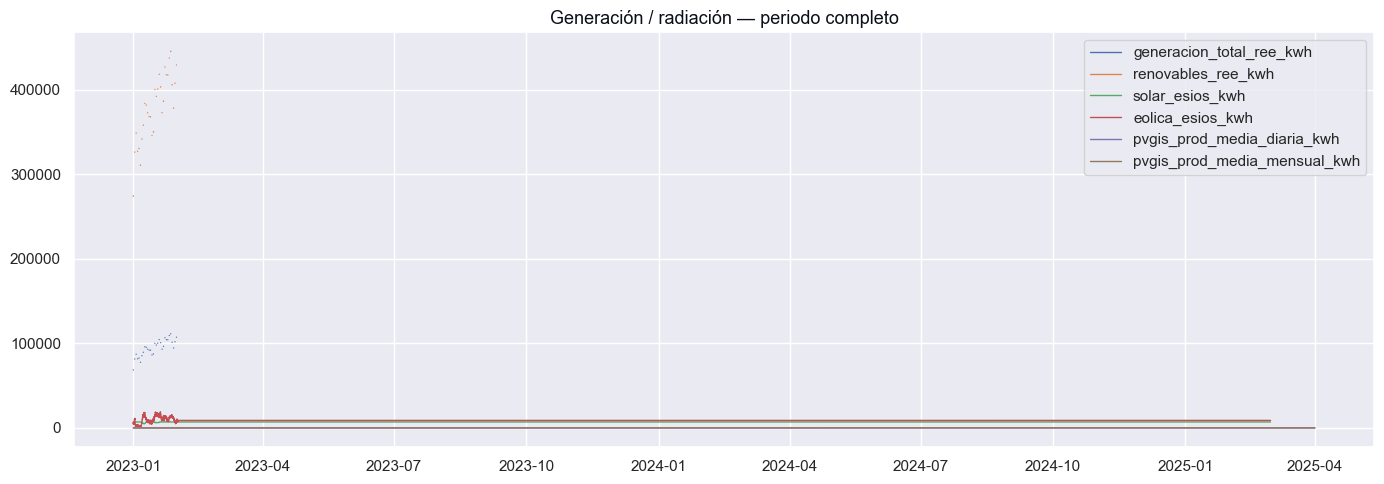

In [10]:
if cols_generacion:
    fig, ax = plt.subplots(figsize=(14, 5))
    for col in cols_generacion:
        ax.plot(df.index, df[col], label=col, linewidth=1)
    ax.set_title("Generación / radiación — periodo completo", color=COLOR_NAVY, fontsize=13)
    ax.legend()
    plt.tight_layout()
    plt.show()


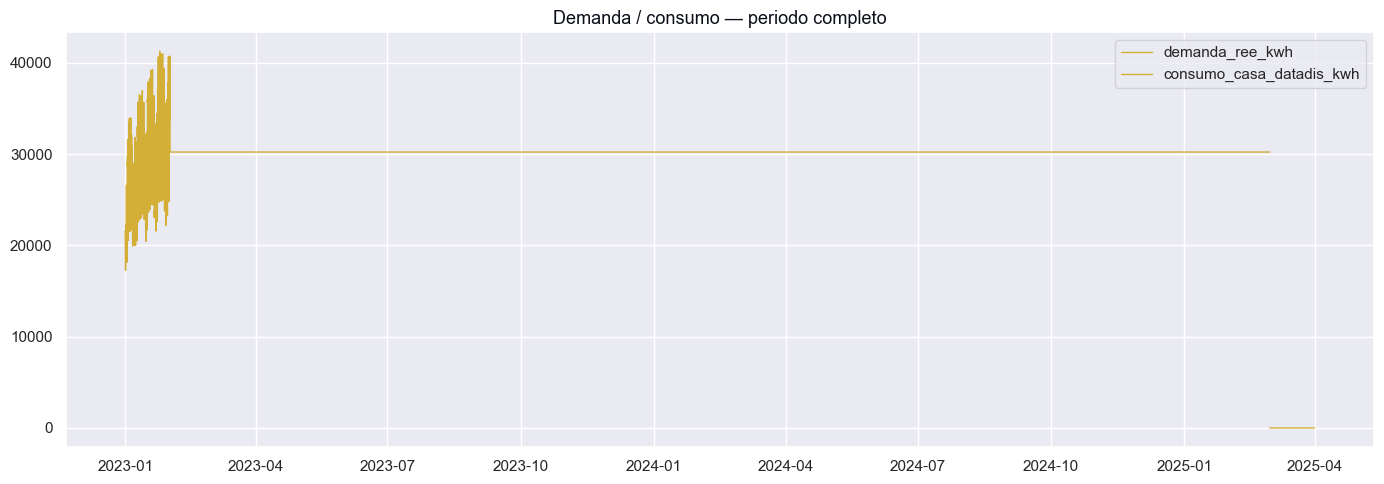

In [11]:
if cols_demanda:
    fig, ax = plt.subplots(figsize=(14, 5))
    for col in cols_demanda:
        ax.plot(df.index, df[col], label=col, linewidth=1, color=COLOR_GOLD)
    ax.set_title("Demanda / consumo — periodo completo", color=COLOR_NAVY, fontsize=13)
    ax.legend()
    plt.tight_layout()
    plt.show()


## 5. Detalle de una semana representativa

Ver todo el periodo junto oculta el patrón diario. Aquí hacemos zoom a los primeros 7
días disponibles para ver el ciclo día/noche de la generación solar frente al consumo.

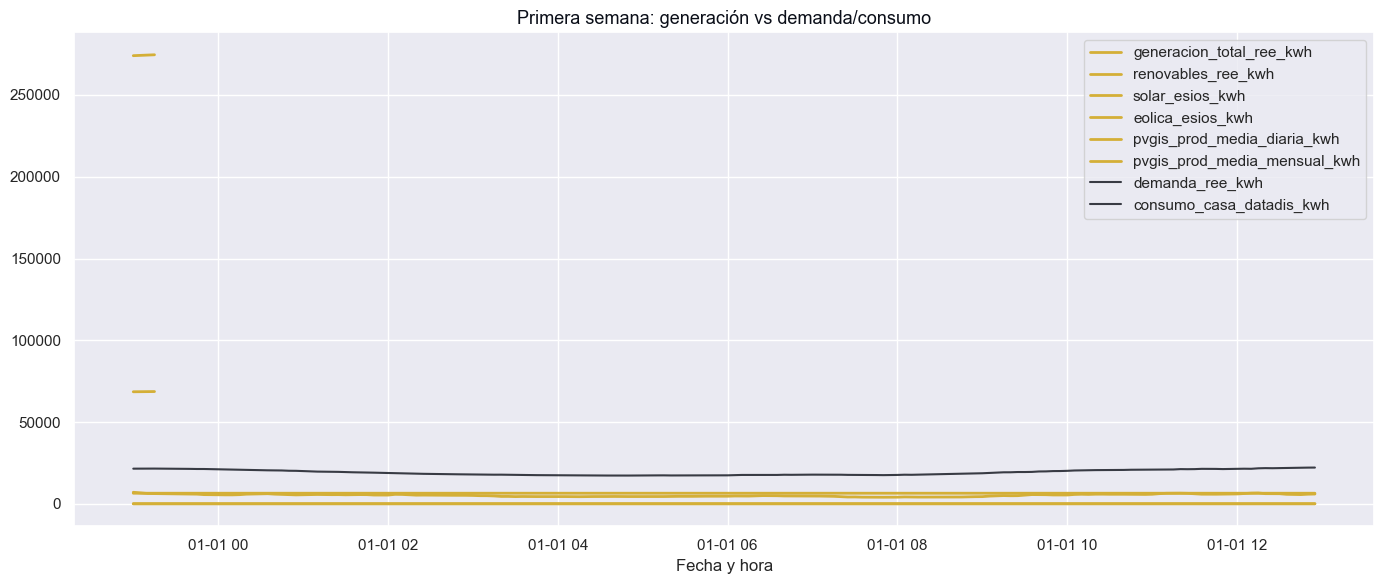

In [12]:
primera_semana = df.iloc[:168]  # 7 días x 24h, si la frecuencia es horaria

if not primera_semana.empty and (cols_generacion or cols_demanda):
    fig, ax = plt.subplots(figsize=(14, 6))
    for col in cols_generacion:
        ax.plot(primera_semana.index, primera_semana[col], label=col, linewidth=2, color=COLOR_GOLD)
    for col in cols_demanda:
        ax.plot(primera_semana.index, primera_semana[col], label=col, linewidth=1.5, color=COLOR_NAVY, alpha=0.8)
    ax.set_title("Primera semana: generación vs demanda/consumo", fontsize=13, color=COLOR_NAVY)
    ax.set_xlabel("Fecha y hora")
    ax.legend()
    plt.tight_layout()
    plt.show()


## 6. Patrón horario promedio

Promediamos por hora del día (independiente de la fecha) para ver el perfil típico de
generación y consumo — esto es clave para el módulo de optimización más adelante.

,generacion_total_ree_kwh,renovables_ree_kwh,solar_esios_kwh,eolica_esios_kwh,pvgis_prod_media_diaria_kwh,pvgis_prod_media_mensual_kwh,demanda_ree_kwh,consumo_casa_datadis_kwh
hora,,,,,,,,
0,NaN,NaN,6829.010753,10100.293011,2.000000,62.120000,24703.682796,NaN
1,NaN,NaN,6808.227882,9906.568365,2.124615,65.963846,23478.509383,0.232839
2,NaN,NaN,6808.292225,9705.943700,2.120896,65.849104,22839.128686,0.070800
3,NaN,NaN,6811.552279,9530.461126,2.124615,65.963846,22657.029491,0.064484
4,NaN,NaN,6813.626344,9533.034946,2.124615,65.963846,23084.857527,0.045935
5,NaN,NaN,6815.991935,9712.000000,2.124615,65.963846,25226.034946,0.061419
6,NaN,NaN,6824.973118,9860.529570,2.124615,65.963846,28707.064516,0.087645
7,NaN,NaN,6839.220430,9804.287634,2.124615,65.963846,30921.489247,0.169774
8,NaN,NaN,6848.663978,9544.086022,2.124615,65.963846,32027.612903,0.201000


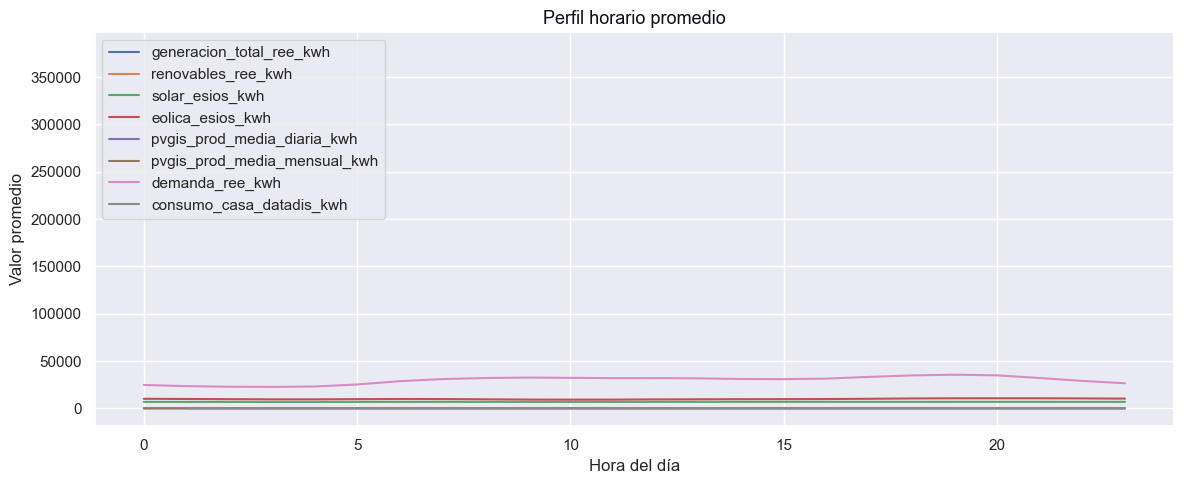

In [13]:
df["hora"] = df.index.hour

cols_perfil = cols_generacion + cols_demanda
if cols_perfil:
    perfil_horario = df.groupby("hora")[cols_perfil].mean()
    display(perfil_horario)

    fig, ax = plt.subplots(figsize=(12, 5))
    perfil_horario.plot(ax=ax)
    ax.set_title("Perfil horario promedio", fontsize=13, color=COLOR_NAVY)
    ax.set_xlabel("Hora del día")
    ax.set_ylabel("Valor promedio")
    plt.tight_layout()
    plt.show()


## 7. Matriz de correlación

Identificamos qué variables climáticas explican mejor la generación fotovoltaica, y si
el consumo tiene alguna relación (esperable que sea baja/nula con el clima, y eso es
justo el problema de negocio: hay que optimizar porque generación y consumo no están
naturalmente alineados).

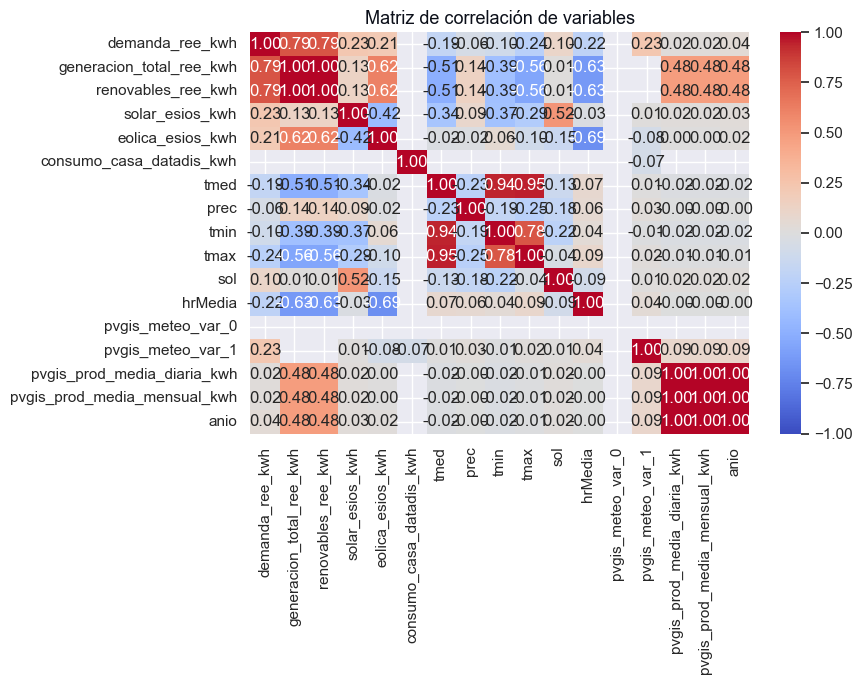

In [14]:
cols_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
cols_numericas = [c for c in cols_numericas if c != "hora"]

if len(cols_numericas) > 1:
    corr = df[cols_numericas].corr()
    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", ax=ax, vmin=-1, vmax=1)
    ax.set_title("Matriz de correlación de variables", fontsize=13, color=COLOR_NAVY)
    plt.tight_layout()
    plt.show()


## 8. Detección visual de outliers

Boxplots por variable para detectar valores atípicos que convenga revisar antes de
pasar a Feature Engineering (un outlier real de generación en un día muy soleado es
válido; un valor negativo de irradiancia, por ejemplo, sería un error de fuente).

Columnas excluidas por estar vacías: ['pvgis_meteo_var_0']


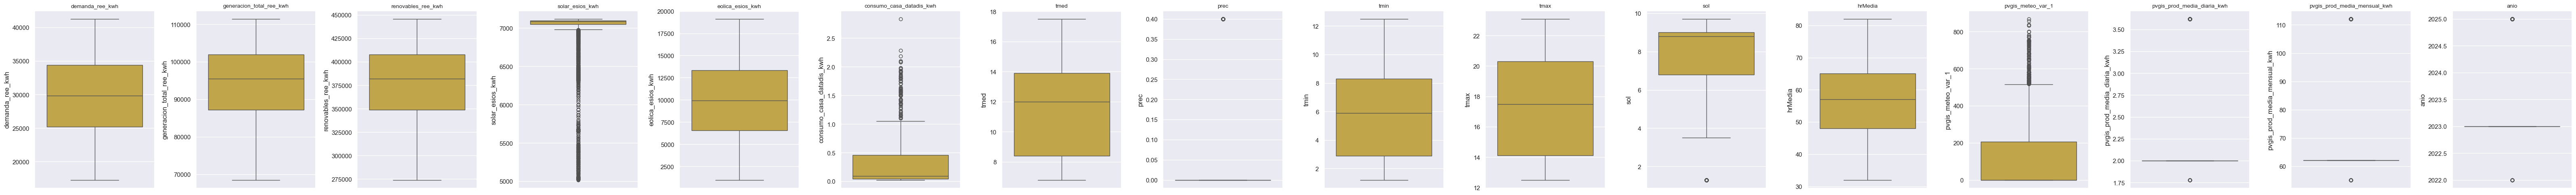

In [15]:
# Excluir columnas 100% vacías antes de graficar boxplots
cols_con_datos = [c for c in cols_numericas if df[c].notna().sum() > 0]

print(f"Columnas excluidas por estar vacías: {[c for c in cols_numericas if c not in cols_con_datos]}")

if cols_con_datos:
    n = len(cols_con_datos)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 5), squeeze=False)
    for ax, col in zip(axes.flatten(), cols_con_datos):
        sns.boxplot(y=df[col], ax=ax, color=COLOR_GOLD)
        ax.set_title(col, fontsize=10)
    plt.tight_layout()
    plt.show()


## 9. Conclusiones del EDA

Completa esta sección con tus propias observaciones tras ejecutar el notebook sobre
los datos reales. Algunas preguntas guía:

- ¿En qué horas se concentra la generación solar? ¿Coincide con las horas de mayor
  consumo del hogar, o hay un desfase claro (el problema que Start Energy AI busca
  resolver)?
- ¿Qué variable climática correlaciona más fuerte con la generación: irradiancia o
  temperatura?
- ¿Hay outliers que deban tratarse antes de modelar, o son variabilidad real del clima?
- ¿La demanda nacional (REE/ESIOS) tiene un patrón horario muy distinto al consumo de
  vivienda (Datadis)? Esto es relevante para justificar por qué hace falta optimización
  a nivel individual y no basta con los datos agregados.

**Siguiente paso:** `03_Feature_Engineering.ipynb` — construir variables derivadas
(hora, día de la semana, festivo/laborable, lags de generación, medias móviles) a
partir de lo observado aquí.


In [16]:
cols_check = ["demanda_ree_kwh", "consumo_casa_datadis_kwh", "tmed", "tmin", "tmax", "prec", "sol", "generacion_total_ree_kwh"]
display(df[cols_check].describe().T[["count", "mean", "min", "max"]])

,count,mean,min,max
demanda_ree_kwh,8931.0,29719.654574,17263.00000,41281.00000
consumo_casa_datadis_kwh,712.0,0.351069,0.02400,2.83600
tmed,8919.0,11.670636,6.80000,17.50000
tmin,8919.0,6.036226,1.20000,12.50000
tmax,8919.0,17.314733,12.50000,23.10000
prec,8919.0,0.012916,0.00000,0.40000
sol,8919.0,7.714127,1.30000,9.70000
generacion_total_ree_kwh,124.0,94613.796012,68509.55875,111438.66675


In [17]:
display(df[["consumo_casa_datadis_kwh"]].describe().T[["count", "mean", "min", "max"]])

,count,mean,min,max
consumo_casa_datadis_kwh,712.0,0.351069,0.024,2.836
